# Data and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE_PATH = os.path.join("..", "..", "data")

In [2]:
label_cod = {
0:'Speed_limit(20km/h)',
1:'Speed_limit(30km/h)',
2:'Speed_limit(50km/h)',
3:'Speed_limit(60km/h)',
4:'Speed_limit(70km/h)',
5:'Speed_limit(80km/h)',
6:'End_of_speed_limit(80km/h)',
7:'Speed_limit(100km/h)',
8:'Speed_limit(120km/h)',
9:'No_passing',
10:'No_passing_veh_over_3.5_tons',
11:'Right-of-way_at_intersection',
12:'Priority_road',
13:'Yield',
14:'Stop',
15:'No_vehicles',
16:'Veh_>_3.5_tons_prohibited',
17:'No_entry',
18:'General_caution',
19:'Dangerous_curve_left',
20:'Dangerous_curve_right',
21:'Double_curve',
22:'Bumpy_road',
23:'Slippery_road',
24:'Road_narrows_on_the_right',
25:'Road_work',
26:'Traffic_signals',
27:'Pedestrians',
28:'Children_crossing',
29:'Bicycles_crossing',
30:'Beware_of_ice/snow',
31:'Wild_animals_crossing',
32:'End_speed_+_passing_limits',
33:'Turn_right_ahead',
34:'Turn_left_ahead',
35:'Ahead_only',
36:'Go_straight_or_right',
37:'Go_straight_or_left',
38:'Keep_right',
39:'Keep_left',
40:'Roundabout_mandatory',
41:'End_of_no_passing',
42:'End_no_passing_veh_>_3.5_tons'
}

In [3]:
def convert_label_to_string(label_cod = None, df = None):
    if label_cod is not None and df is not None:
        df["Label"] = df["ClassId"].map(label_cod)
        return df
    return None

In [4]:
df_train = pd.read_csv(os.path.join(BASE_PATH, "Train.csv"))
df_test = pd.read_csv(os.path.join(BASE_PATH, "Test.csv"))
df_meta = pd.read_csv(os.path.join(BASE_PATH, "Meta.csv"))

df_train = convert_label_to_string(label_cod = label_cod, df = df_train)
df_test = convert_label_to_string(label_cod = label_cod, df = df_test)
df_meta = convert_label_to_string(label_cod = label_cod, df = df_meta)

# View Example

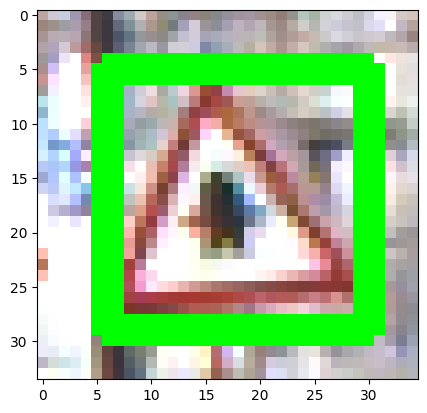

In [5]:
import cv2

test = df_test.iloc[25]
image_path = os.path.join(BASE_PATH, test["Path"])
roiX1, roiY1, roiX2, roiY2 = test[["Roi.X1", "Roi.Y1", "Roi.X2", "Roi.Y2"]]

img = cv2.imread(image_path)

cv2.rectangle(img, (roiX1, roiY1), (roiX2, roiY2), (0,255,0), 2)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img);

# Image distribution plot

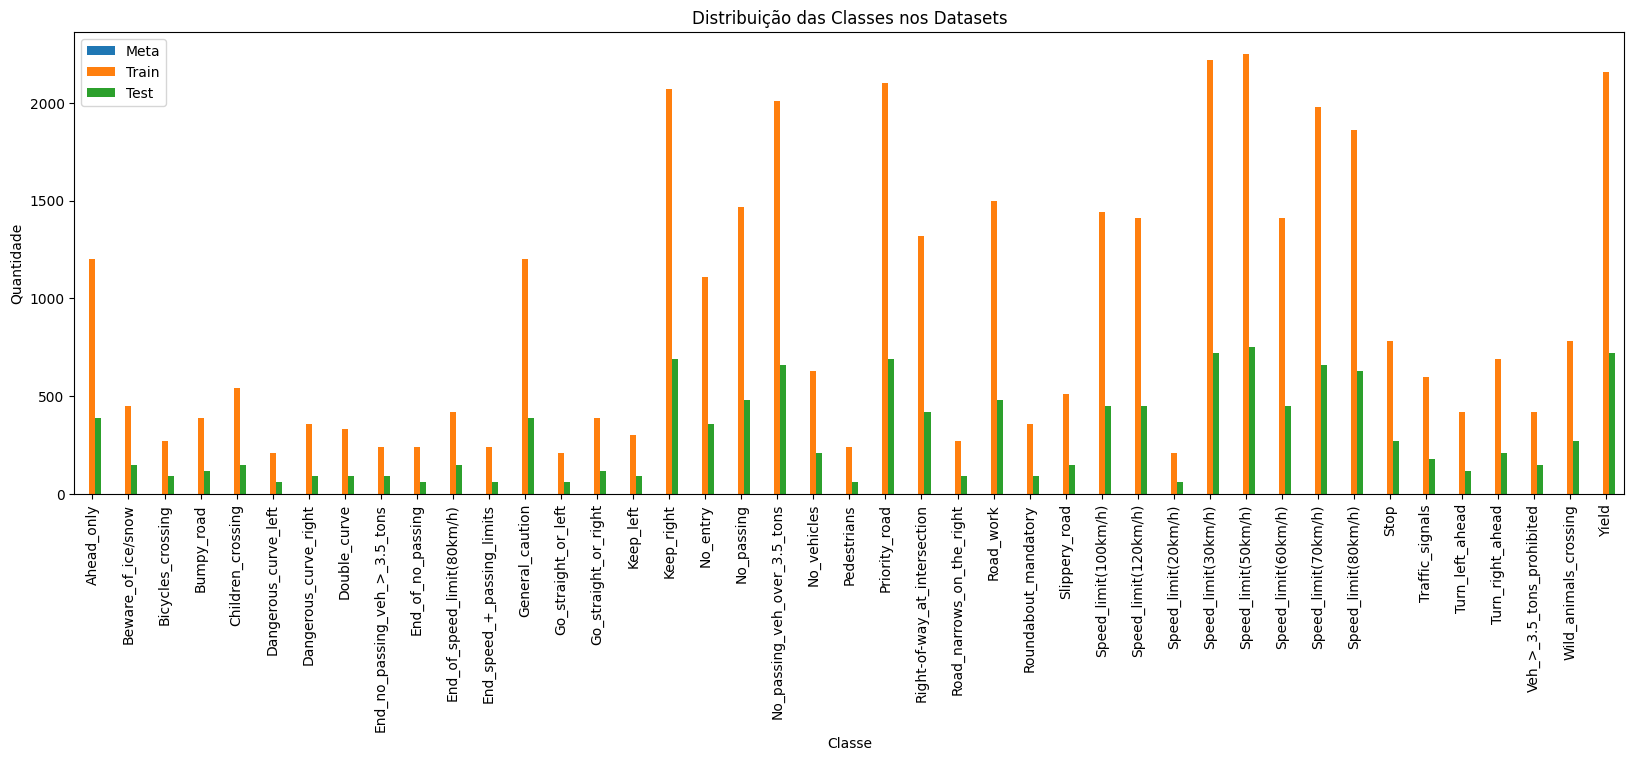

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


meta_counts = df_meta["Label"].value_counts().sort_index()
train_counts = df_train["Label"].value_counts().sort_index()
test_counts = df_test["Label"].value_counts().sort_index()

df_plot = pd.DataFrame({
    "Meta": meta_counts,
    "Train": train_counts,
    "Test": test_counts
})

df_plot.plot(kind="bar", figsize=(20,6))

plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.title("Distribuição das Classes nos Datasets")
plt.xticks(rotation=90)

plt.show()

In [7]:
features = ["Label", "ClassId", "Path"]

df_train = df_train[features]
df_test = df_test[features]
df_meta = df_meta[features]

In [8]:
df_train.to_csv("df_train.csv")
df_test.to_csv("df_test.csv")
df_meta.to_csv("df_meta.csv")